## Variable Types Review

In this notebook, we'll review types of variable and tools to describe those variables or relationships between those variables.

For this, we'll be using the [Car Features and MSRP](https://www.kaggle.com/datasets/CooperUnion/cardataset) dataset.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
cars = pd.read_csv('../data/cars.csv')
cars.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


## Categorical Variables

Recall that a **categorical variable** is a label or group, without numeric meaning.

The primary way to summarize a categorical variable is through counts or proportions.

**Question:** Which variables in this dataset are categorical?

For example, let's say we wanted to look at the Vehicle Size variable.

In [5]:
cars['Vehicle Size']

0        Compact
1        Compact
2        Compact
3        Compact
4        Compact
          ...   
11909    Midsize
11910    Midsize
11911    Midsize
11912    Midsize
11913    Midsize
Name: Vehicle Size, Length: 11914, dtype: object

If we wanted to see how common each vehicle size is, we can use value_counts.

In [7]:
cars['Vehicle Size'].value_counts()

Vehicle Size
Compact    4764
Midsize    4373
Large      2777
Name: count, dtype: int64

And if we instead want proportions, we can use the normalize argument.

In [9]:
cars['Vehicle Size'].value_counts(normalize=True)

Vehicle Size
Compact    0.399866
Midsize    0.367047
Large      0.233087
Name: proportion, dtype: float64

The main type of plot used for categorical variables is the **bar chart**.

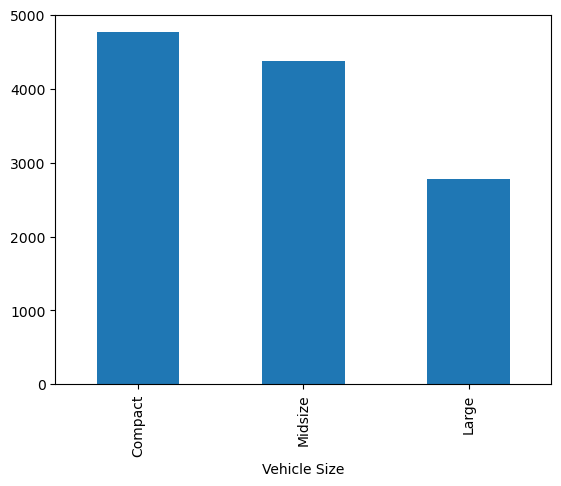

In [11]:
(
    cars
    ['Vehicle Size']
    .value_counts()
    .plot(kind="bar")
);

Another type of plot that can be used for categorical variables is the pie chart. However, pie charts should generally be avoided. For example, notice how it is difficult to compare the sizes of the midsize and the compact categories, where for the bar chart, the relative sizes of the categories are very clear.

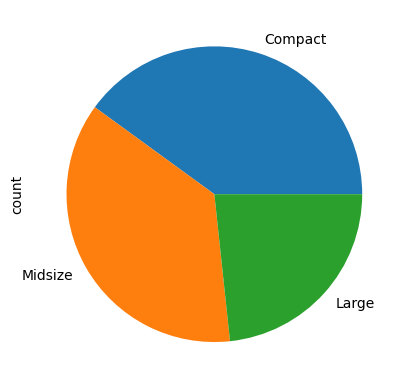

In [13]:
(
    cars
    ['Vehicle Size']
    .value_counts()
    .plot(kind="pie")
);

Another question that is important to ask is if there are any missing values. We can do this using value_counts by using the dropna argument.

In [15]:
cars['Vehicle Size'].value_counts(dropna=False)

Vehicle Size
Compact    4764
Midsize    4373
Large      2777
Name: count, dtype: int64

We can see that there are no missing values for the vehicle size varible. Compare this to the Engine Fuel Type variable.

In [17]:
cars['Engine Fuel Type'].value_counts(dropna=False)

Engine Fuel Type
regular unleaded                                7172
premium unleaded (required)                     2009
premium unleaded (recommended)                  1523
flex-fuel (unleaded/E85)                         899
diesel                                           154
electric                                          66
flex-fuel (premium unleaded required/E85)         54
flex-fuel (premium unleaded recommended/E85)      26
flex-fuel (unleaded/natural gas)                   6
NaN                                                3
natural gas                                        2
Name: count, dtype: int64

Another way is to use the isna method. This returns a Boolean Series.

In [19]:
cars['Engine Fuel Type'].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
11909    False
11910    False
11911    False
11912    False
11913    False
Name: Engine Fuel Type, Length: 11914, dtype: bool

Then to get a count, we can sum this series.

In [21]:
cars['Engine Fuel Type'].isna().sum()

3

What if we want to look into the rows with missing values? Here, we can use .loc.

In [23]:
cars.loc[cars['Engine Fuel Type'].isna()]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11321,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,25,17,481,17199
11322,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,25,17,481,20199
11323,Suzuki,Verona,2004,NaN,155.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,25,17,481,18499


Notice that we have three rows for the 2004 Suzuki Verona that are identical except for the MSRP.

This could be due to how the data was collected; it was scraped from Edmunds and Twitter, so these values may have changed over time. We'll just make note of this, but if we were working with this data more, we might want to track down the source of the issue and determine what correction we could take.

Varibles like the Number of Doors are numbers, but we might want to treat them more like categorical variables.

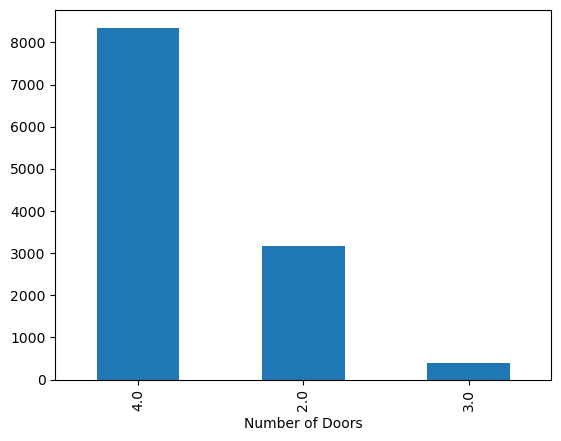

In [26]:
(
    cars
    ['Number of Doors']
    .value_counts()
    .plot(kind="bar")
);

Four door cars are the most common, with three door being most rare. Let's investigate these further.

In [28]:
cars[cars['Number of Doors'] == 3]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1331,Ford,Aerostar,1995,regular unleaded,135.0,6.0,AUTOMATIC,rear wheel drive,3.0,NaN,Midsize,Cargo Minivan,22,16,5657,2000
1332,Ford,Aerostar,1995,regular unleaded,135.0,6.0,AUTOMATIC,rear wheel drive,3.0,NaN,Midsize,Passenger Minivan,22,15,5657,2000
1333,Ford,Aerostar,1995,regular unleaded,155.0,6.0,AUTOMATIC,all wheel drive,3.0,NaN,Large,Passenger Minivan,18,14,5657,2000
1334,Ford,Aerostar,1995,regular unleaded,135.0,6.0,AUTOMATIC,rear wheel drive,3.0,NaN,Large,Passenger Minivan,22,15,5657,2000
1335,Ford,Aerostar,1996,regular unleaded,140.0,6.0,AUTOMATIC,rear wheel drive,3.0,NaN,Midsize,Passenger Minivan,21,15,5657,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11426,Plymouth,Voyager,2000,regular unleaded,150.0,4.0,AUTOMATIC,front wheel drive,3.0,NaN,Midsize,Passenger Minivan,24,18,535,2008
11427,Ford,Windstar Cargo,2001,regular unleaded,200.0,6.0,AUTOMATIC,front wheel drive,3.0,NaN,Midsize,Cargo Minivan,22,16,5657,20220
11428,Ford,Windstar Cargo,2002,regular unleaded,200.0,6.0,AUTOMATIC,front wheel drive,3.0,NaN,Midsize,Cargo Minivan,21,16,5657,20585
11429,Ford,Windstar Cargo,2003,regular unleaded,200.0,6.0,AUTOMATIC,front wheel drive,3.0,NaN,Midsize,Cargo Minivan,22,16,5657,21075


If we look at vehicle styles, we see that three door vehicles are commonly vans.

In [30]:
cars[cars['Number of Doors'] == 3]['Vehicle Style'].value_counts()

Vehicle Style
Passenger Van          128
Cargo Van               95
Passenger Minivan       72
Extended Cab Pickup     47
2dr Hatchback           30
Cargo Minivan           23
Name: count, dtype: int64

## Quantitative Variables

A quantitative variable is one that has numeric meaning.

When looking at quantitative variable, we can start by looking at some summary statistics.

In [32]:
cars['highway MPG'].describe()

count    11914.000000
mean        26.637485
std          8.863001
min         12.000000
25%         22.000000
50%         26.000000
75%         30.000000
max        354.000000
Name: highway MPG, dtype: float64

Here, we can see "typical" values for highway fuel mileage. We can also potentially spot problems in the dataset. For example, 354 seems a little bit high. Let's investigate.

In [34]:
cars.nlargest(5, 'highway MPG')

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1119,Audi,A6,2017,premium unleaded (recommended),252.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,354,24,3105,51600
5790,BMW,i3,2015,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,111,137,3916,42400
5791,BMW,i3,2016,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,111,137,3916,42400
5792,BMW,i3,2017,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,"Hatchback,Luxury",Compact,4dr Hatchback,111,137,3916,42400
1983,Chevrolet,Bolt EV,2017,electric,200.0,NaN,DIRECT_DRIVE,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,110,128,1385,40905


It appears that there is a mistake in the highway MPG value for the Audi A6. Let's drop the problem value.

In [36]:
cars['highway MPG'] = cars['highway MPG'].replace({354: np.nan})

For plots, we can start with a histogram.

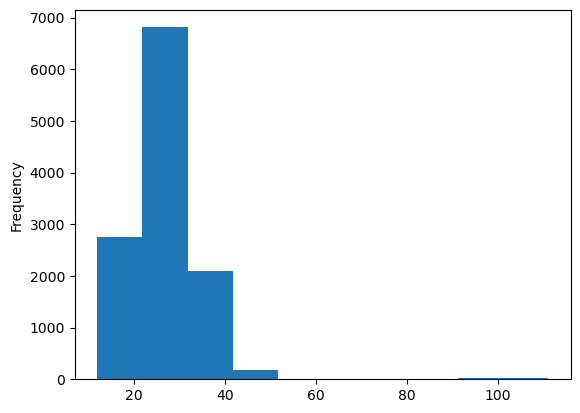

In [38]:
cars['highway MPG'].plot(kind="hist");

A boxplot can also be useful.

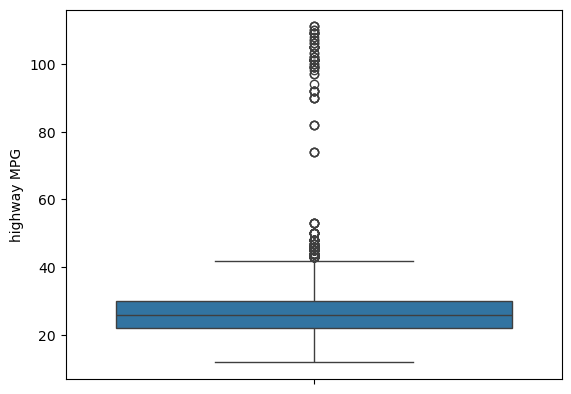

In [40]:
sns.boxplot(data=cars, y='highway MPG');

From both of these plots. we can see that the dataset is right skewed, having a small number of cars with unusually high highway fuel mileage. 

In terms of the variability, we can look at the standard deviation, but with a skewed dataset, sometimes this can be misleading. Looking at the quartiles, we can see that half of vehicles have a highway MPG between 22 and 30.

## Relationships Between Variables

When comparing two numeric variables, we can use a scatterplot.

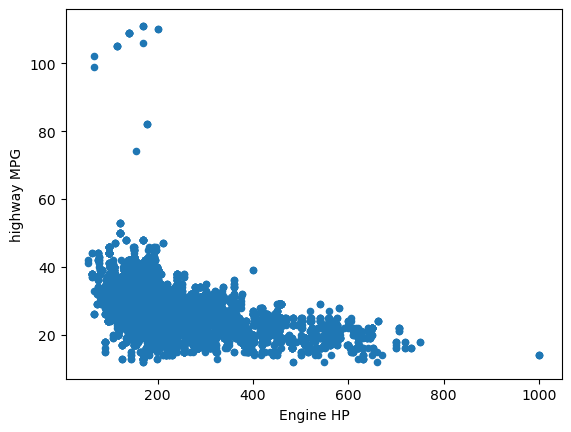

In [43]:
cars.plot(
    kind="scatter",
    x="Engine HP",
    y="highway MPG"
);

We might want to follow that up with a correlation calculation.

In [45]:
cars[['Engine HP', 'highway MPG']].corr()

,Engine HP,highway MPG
Engine HP,1.000000,-0.441559
highway MPG,-0.441559,1.000000


If we want to compare a categorical variable to a numeric, groupby can be used.

In [47]:
cars.groupby('Engine Fuel Type')['highway MPG'].mean().sort_values()

Engine Fuel Type
flex-fuel (premium unleaded required/E85)       19.925926
flex-fuel (unleaded/E85)                        22.629588
premium unleaded (required)                     23.896964
flex-fuel (unleaded/natural gas)                25.000000
flex-fuel (premium unleaded recommended/E85)    25.346154
regular unleaded                                26.645008
premium unleaded (recommended)                  28.458607
diesel                                          36.564935
natural gas                                     38.000000
electric                                        99.590909
Name: highway MPG, dtype: float64

Or a grouped plot of some kind.

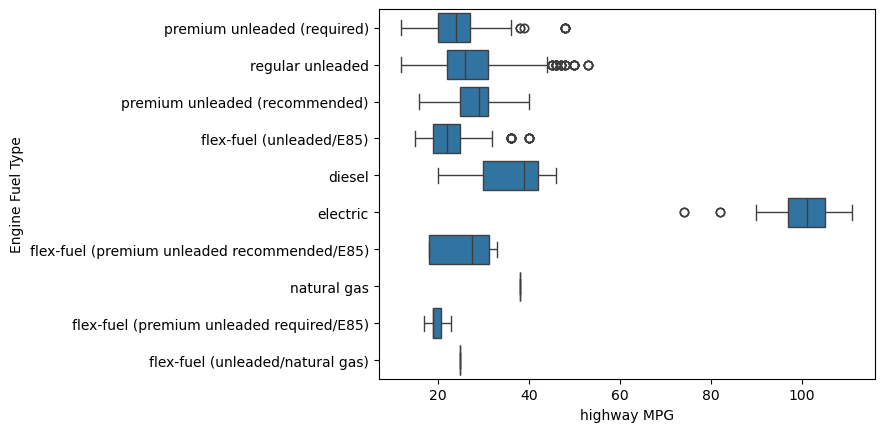

In [49]:
sns.boxplot(data=cars, x="highway MPG", y="Engine Fuel Type");

Finally, we might want to compare two categorical variables.

We can do a cross-tabulation.

In [51]:
pd.crosstab(
    cars['Driven_Wheels'],
    cars['Transmission Type']
)

Transmission Type,AUTOMATED_MANUAL,AUTOMATIC,DIRECT_DRIVE,MANUAL,UNKNOWN
Driven_Wheels,,,,,
all wheel drive,198,1940,11,204,0
four wheel drive,0,1056,0,345,2
front wheel drive,304,3056,43,1380,4
rear wheel drive,124,2214,14,1006,13


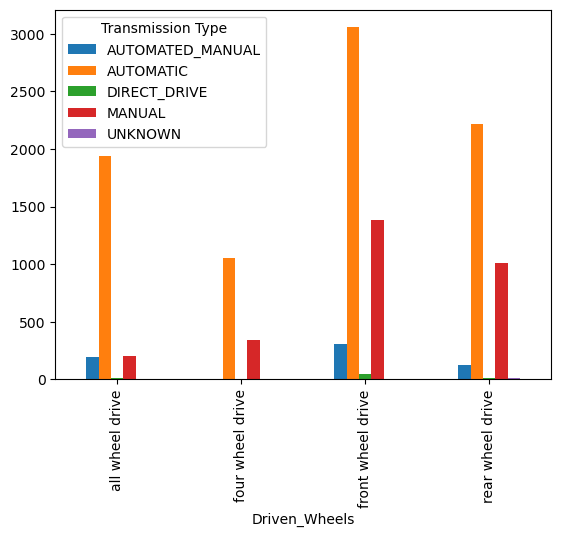

In [52]:
pd.crosstab(
    cars['Driven_Wheels'],
    cars['Transmission Type']
).plot(kind="bar");

We can also do a stacked bar chart.

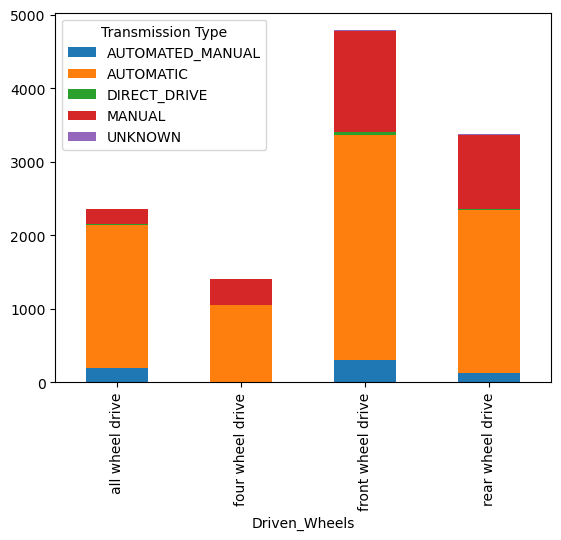

In [54]:
pd.crosstab(
    cars['Driven_Wheels'],
    cars['Transmission Type']
).plot(kind="bar", stacked=True);

Or, we might want to compare proportions by group. We can do this by normalizing the cross tabulation.

In [56]:
pd.crosstab(
    cars['Driven_Wheels'],
    cars['Transmission Type'],
    normalize='index'
)

Transmission Type,AUTOMATED_MANUAL,AUTOMATIC,DIRECT_DRIVE,MANUAL,UNKNOWN
Driven_Wheels,,,,,
all wheel drive,0.084148,0.824479,0.004675,0.086698,0.000000
four wheel drive,0.000000,0.752673,0.000000,0.245902,0.001426
front wheel drive,0.063505,0.638396,0.008983,0.288281,0.000836
rear wheel drive,0.036784,0.656778,0.004153,0.298428,0.003856


This can then be used in a stacked 100% bar chart.

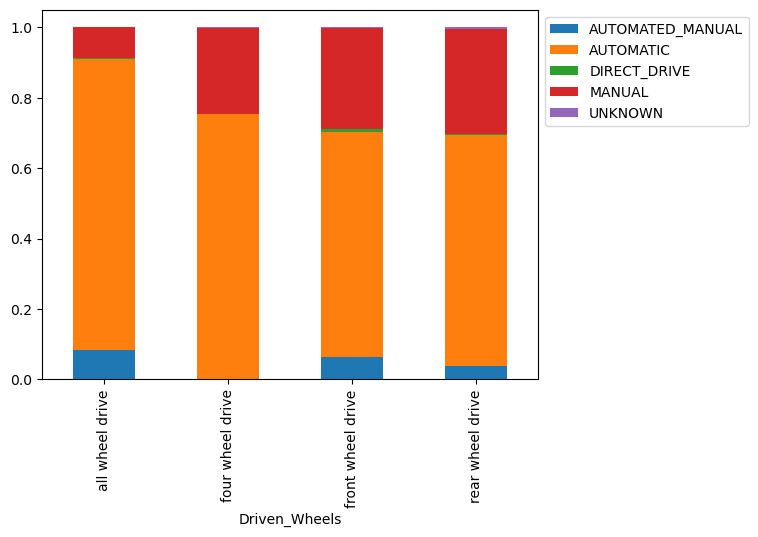

In [58]:
pd.crosstab(
    cars['Driven_Wheels'],
    cars['Transmission Type'],
    normalize='index'
).plot(kind="bar", stacked=True)
plt.legend(bbox_to_anchor=(1,1));

If one of your variables is time (or some kind of sequential variable), it can make sense to do a line chart to visualize trends.

For example, we might want to plot how average highway MPG has changed over time.

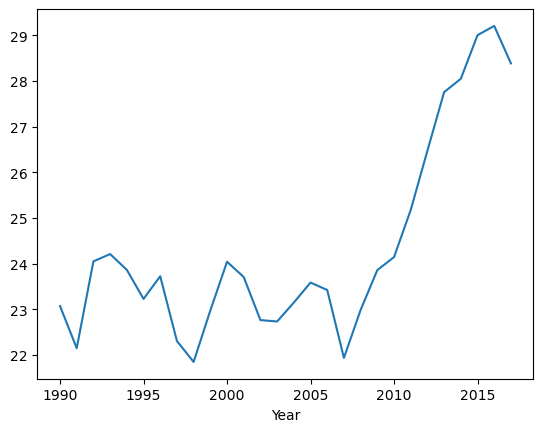

In [60]:
cars.groupby('Year')['highway MPG'].mean().plot(kind="line");

## Three or More Variables

In some cases, you might want to compare more than two variables. This can be done by changing the color or size of points.

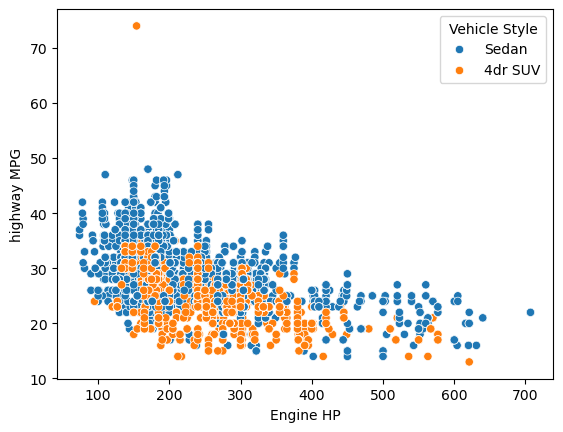

In [62]:
sns.scatterplot(
    data=cars[cars['Vehicle Style'].isin(['Sedan', '4dr SUV'])],
    x="Engine HP",
    y="highway MPG",
    hue="Vehicle Style"
);

We can create a bubble chart by varying the size of points.

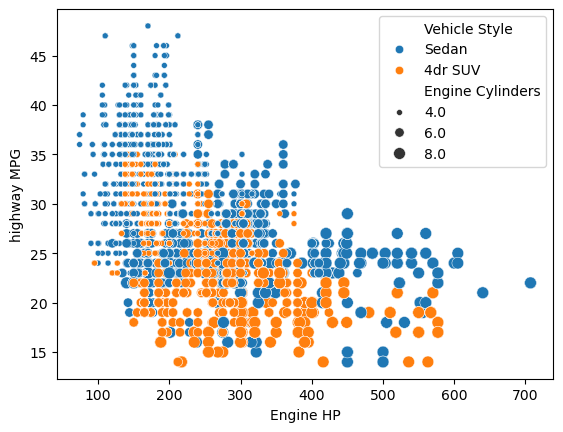

In [64]:
sns.scatterplot(
    data=(
        cars
        .loc[cars['Vehicle Style'].isin(['Sedan', '4dr SUV'])]
        .loc[cars['Engine Cylinders'].isin([4,6,8])]
    ),
    x="Engine HP",
    y="highway MPG",
    hue="Vehicle Style",
    size="Engine Cylinders"
);

It could also mean creating multiple plots to see how trends or relationships differ across categories.

For example, we could use the subplots function to make two histograms.

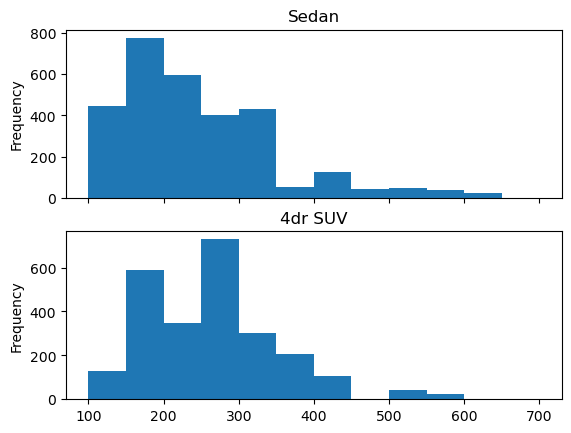

In [66]:
fig, axes = plt.subplots(nrows=2, sharex=True)
bins = np.arange(start=100, stop=750, step=50)

for style, ax in zip(['Sedan', '4dr SUV'], axes):
    cars[cars['Vehicle Style']==style]['Engine HP'].plot(kind="hist", ax=ax, title=style, bins=bins);

Or making multiple line plots using seaborn.

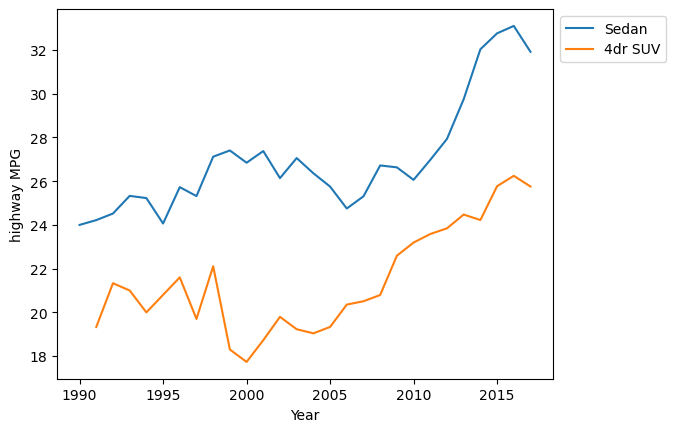

In [68]:
sns.lineplot(
    data=(
        cars
        [cars['Vehicle Style'].isin(['Sedan', '4dr SUV'])]
        .groupby(['Year', 'Vehicle Style'])
        ['highway MPG']
        .mean()
        .reset_index()
    ),
    x="Year",
    y="highway MPG",
    hue="Vehicle Style"
)
plt.legend(bbox_to_anchor=(1, 1));